# Session 14 — follow-up: does the re-draw cost the MoE its win?

In the main notebook ([`S14.ipynb`](S14.ipynb)) the MoE kept training but only tied the
continue-dense control after 50M tokens. The measured conversion jump points at the likely
reason:

- routing alone (shared half plus 4 of 16 sampled slices) cost +0.14 in validation loss;
- drop-upcycling's re-draw of half of every expert's neurons (r = 0.5) raised it to +0.52.

The MoE then spent about 10M tokens recovering.

This notebook runs **the same MoE with r = 0**, re-drawing nothing, and changes nothing else. It
uses hard top-k routing, so it pairs with the main notebook's `moe_hard` run (r = 0.5, hard
top-k), and r is the only difference between them.

**Prediction, written before the run.**
- A smaller jump, about +0.14 (measured in the main notebook).
- A faster recovery.
- A final loss below the r = 0.5 run's.

Whether it also beats the dense control is the open question. The main run's MoE had more
capacity and was gaining on the control at every evaluation, so removing most of the handicap
*should* let it finish ahead. But with nothing re-drawn, the experts also start more alike, and
the drop-upcycling paper's argument is that this diversity is what makes experts specialise.

**Nothing is re-implemented here.** The data, model, MoE, conversion and training-loop cells are
executed verbatim from [`notebook_src.py`](notebook_src.py). The dense phase is **retrained**,
because the main run kept its checkpoint only in memory. It uses the same seed, data and
schedule, and a GPU rerun is not guaranteed to be bit-identical, so the rerun is compared with
the main run's dense result. **The continue-dense control is also rerun** from the new
checkpoint. The r = 0 MoE is therefore compared with a control grown from the very same
weights, and the two controls together measure how much a same-seed GPU rerun moves the final
loss. Results are added to the main `results.json` under `r0`.

In [1]:
import json, pathlib, re, time
import numpy as np

SRC = pathlib.Path("notebook_src.py").read_text()
CELLS = [c for c in re.split(r"^# %%.*$", SRC, flags=re.M) if c.strip()]

def cell_with(marker):
    hits = [c for c in CELLS if marker in c]
    assert len(hits) == 1, (marker, len(hits))
    return hits[0]

# environment, data, model, MoE layer, conversion, training loop — in notebook order
NEEDED = ["T_START = time.perf_counter()", "def fetch(", "TOK_PATH = pathlib.Path",
          "def encode_to(", "class Attn(", "GAMMA = 0.001", "MOE = dict(", "def lr_dense("]
for marker in NEEDED:
    exec(cell_with(marker), globals())

MAIN = json.loads(pathlib.Path("results.json").read_text())
assert SMOKE or (MAIN["model"]["dense_params"] == N_DENSE and MAIN["data"]["steps_per_phase"] == STEPS_PHASE)
EARLY = (10, 25, 50, 100, 150, 200, 300, 450) if not SMOKE else (5, 10)
print(f"\nre-using the main run's settings: {N_DENSE:,} dense parameters, {STEPS_PHASE} steps per phase, "
      f"batch {BATCH}, lr {LR}")

{
  "device": "cuda",
  "torch": "2.5.1+cu121",
  "smoke": false,
  "python": "3.10.12",
  "gpu": "Tesla T4",
  "gpu_mem_gib": 14.56,
  "sm": "75"
}


585,700 training stories, 27,629 validation stories


encoded in 4s: 102.62M train tokens, 5.42M validation tokens; two phases need 100.01M


dense model: 17.54M parameters, of which 8 × 1.182M = 9.45M in the feed-forward blocks

re-using the main run's settings: 17,538,816 dense parameters, 1526 steps per phase, batch 64, lr 0.001


## Phase A again — dense, 50M tokens, same seed

In [2]:
R0 = {}
torch.manual_seed(1234)
dense = GPT(**CFG)
R0["dense_rerun"], _, EV_DENSE = train("dense_rerun", dense, STEPS_PHASE, 0, lr_dense)
CKPT = copy.deepcopy(dense.state_dict())
DENSE_VAL2 = R0["dense_rerun"]["final_val_loss"]
print(f"dense rerun {DENSE_VAL2:.4f}  vs main run {MAIN['runs']['dense']['final_val_loss']:.4f}  "
      f"(Δ {DENSE_VAL2 - MAIN['runs']['dense']['final_val_loss']:+.4f})")

  dense_rerun  step     0/1526  val 9.1058


  dense_rerun  step   152/1526  val 3.3133  train 3.2803


  dense_rerun  step   305/1526  val 2.6025  train 2.6116


  dense_rerun  step   457/1526  val 2.2879  train 2.3200


  dense_rerun  step   610/1526  val 2.1048  train 2.0652


...

  dense_rerun  step  1220/1526  val 1.7850  train 1.7661


  dense_rerun  step  1373/1526  val 1.7468  train 1.7297


  dense_rerun  step  1526/1526  val 1.7121  train 1.7472


  → dense_rerun: val 9.1058 → 1.7121, 95.4K tok/s, 9.1 min


dense rerun 1.7121  vs main run 1.7119  (Δ +0.0002)


## The conversion at r = 0 and r = 0.5, on this checkpoint

In [3]:
def val_of(model):
    model.to(DEVICE); v = evaluate(model)[0]; model.cpu(); return v

CONV2 = {"dense": DENSE_VAL2, "sample_r0": val_of(convert(dense, "sample", r=0.0)),
         "sample_r05": val_of(convert(dense, "sample", r=R_DROP))}
CONV2["jump_r0"] = CONV2["sample_r0"] - DENSE_VAL2
CONV2["jump_r05"] = CONV2["sample_r05"] - DENSE_VAL2
print(f"conversion jump on the rerun checkpoint: r=0 {CONV2['jump_r0']:+.4f}, r=0.5 {CONV2['jump_r05']:+.4f}  "
      f"(main run: {MAIN['conversion']['jump_r0']:+.4f}, {MAIN['conversion']['jump_r05']:+.4f})")

conversion jump on the rerun checkpoint: r=0 +0.1360, r=0.5 +0.5227  (main run: +0.1434, +0.5160)


## Phase B — MoE with r = 0, hard top-k, +50M tokens

In [4]:
torch.manual_seed(99)
moe0 = convert(dense, "sample", r=0.0)
R0["moe_r0"], _, EV_MOE0 = train("moe_r0", moe0, STEPS_PHASE, STEPS_PHASE, lr_cont,
                                 sample_steps=0, eval_extra=EARLY)
del moe0

  moe_r0       step     0/1526  val 1.8482  dead(val) 0


  moe_r0       step    10/1526  val 1.7524  train 1.7751  dead(val) 0


  moe_r0       step    25/1526  val 1.7392  train 1.6786  dead(val) 0


  moe_r0       step    50/1526  val 1.7515  train 1.7173  dead(val) 0


  moe_r0       step   100/1526  val 1.7347  train 1.7706  dead(val) 0


...

  moe_r0       step  1068/1526  val 1.5793  train 1.6035  dead(val) 0


  moe_r0       step  1220/1526  val 1.5667  train 1.5251  dead(val) 0


  moe_r0       step  1373/1526  val 1.5011  train 1.4631  dead(val) 0


  moe_r0       step  1526/1526  val 1.4404  train 1.5166  dead(val) 0


  → moe_r0: val 1.8482 → 1.4404, 45.3K tok/s, 19.7 min


## Control again — dense, +50M tokens, from the rerun checkpoint

In [5]:
torch.manual_seed(99)
dense.load_state_dict(CKPT)
R0["dense_cont_rerun"], _, EV_CONT2 = train("dense_cont_rerun", copy.deepcopy(dense), STEPS_PHASE,
                                            STEPS_PHASE, lr_cont, eval_extra=EARLY)

  dense_cont_rerun step     0/1526  val 1.7121


  dense_cont_rerun step    10/1526  val 1.6682  train 1.6898


  dense_cont_rerun step    25/1526  val 1.6851  train 1.6195


  dense_cont_rerun step    50/1526  val 1.7063  train 1.6715


  dense_cont_rerun step   100/1526  val 1.6955  train 1.7332


...

  dense_cont_rerun step  1068/1526  val 1.5769  train 1.6001


  dense_cont_rerun step  1220/1526  val 1.5649  train 1.5280


  dense_cont_rerun step  1373/1526  val 1.5032  train 1.4663


  dense_cont_rerun step  1526/1526  val 1.4459  train 1.5214


  → dense_cont_rerun: val 1.7121 → 1.4459, 95.4K tok/s, 9.3 min


## Comparison

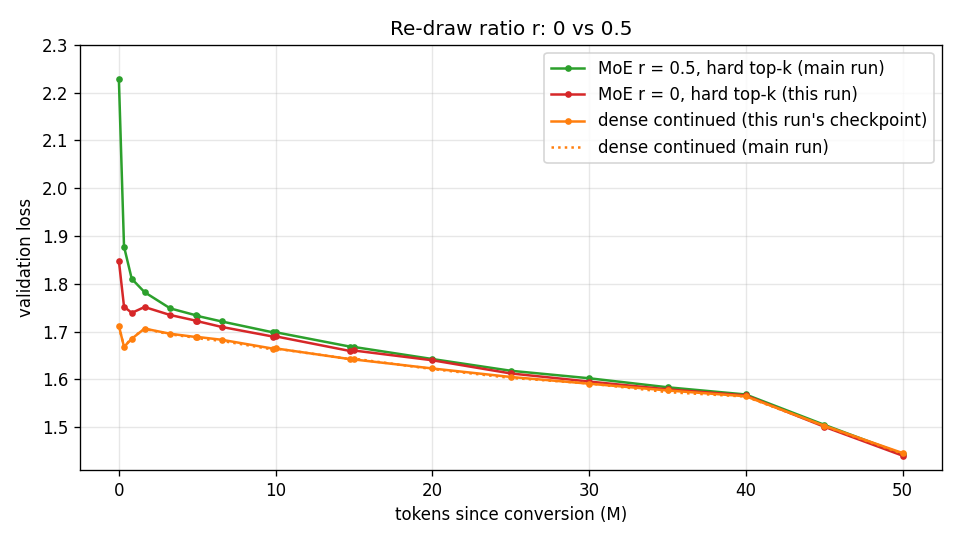

conversion                       {'dense': 1.712122417986393, 'sample_r0': 1.8481529504060745, 'sample_r05': 2.2348583415150642, 'jump_r0': 0.13603053241968155, 'jump_r05': 0.5227359235286713}
dense_rerun_val                  1.712122417986393
dense_rerun_delta_vs_main        0.00024058297276496887
moe_r0_val_start                 1.8481529504060745
moe_r0_val_end                   1.4404304288327694
control_val_end                  1.445898000150919
control_rerun_delta_vs_main      0.001440931111574173
moe_r0_vs_control                -0.005467571318149567
moe_r0_vs_moe_r05_hard           -0.003273855894804001
moe_r0_recovery_tokens_M         6.5536
moe_r0_final_val_maxvio          0.048186302185058594
moe_r0_final_val_dead            0
moe_r0_dead_per_step_max         0
moe_r0_tokens_per_s              45290.47305687125


In [6]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

main_c = MAIN["curves"]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.asarray(main_c["moe_hard"]["tokens"]) / 1e6, main_c["moe_hard"]["val_loss"], "o-", ms=3,
        color="#2ca02c", label="MoE r = 0.5, hard top-k (main run)")
ax.plot(np.asarray(EV_MOE0["tokens"]) / 1e6, EV_MOE0["val_loss"], "o-", ms=3, color="#d62728",
        label="MoE r = 0, hard top-k (this run)")
ax.plot(np.asarray(EV_CONT2["tokens"]) / 1e6, EV_CONT2["val_loss"], "o-", ms=3, color="#ff7f0e",
        label="dense continued (this run's checkpoint)")
ax.plot(np.asarray(main_c["dense_cont"]["tokens"]) / 1e6, main_c["dense_cont"]["val_loss"], ":",
        color="#ff7f0e", label="dense continued (main run)")
ax.set_ylim(min(EV_MOE0["val_loss"] + EV_CONT2["val_loss"]) - 0.03, 2.3)
ax.set_xlabel("tokens since conversion (M)"); ax.set_ylabel("validation loss")
ax.set_title("Re-draw ratio r: 0 vs 0.5"); ax.grid(alpha=.3); ax.legend()
fig.tight_layout(); fig.savefig("assets/r0_vs_r05.png", dpi=120); plt.close(fig)
display(Image("assets/r0_vs_r05.png"))

def first_below(ev, level):
    for t_, v_ in zip(ev["tokens"], ev["val_loss"]):
        if v_ <= level: return t_ / 1e6
    return float("nan")

rows = [json.loads(l) for l in open("logs/train_moe_r0.jsonl") if l.strip()]
steps_rows = [r for r in rows if not r.get("eval")]
ld = np.array(EV_MOE0["load"][-1])
R0_SUMMARY = {
    "conversion": CONV2,
    "dense_rerun_val": DENSE_VAL2,
    "dense_rerun_delta_vs_main": DENSE_VAL2 - MAIN["runs"]["dense"]["final_val_loss"],
    "moe_r0_val_start": R0["moe_r0"]["val_start"], "moe_r0_val_end": R0["moe_r0"]["final_val_loss"],
    "control_val_end": R0["dense_cont_rerun"]["final_val_loss"],
    "control_rerun_delta_vs_main": R0["dense_cont_rerun"]["final_val_loss"] - MAIN["runs"]["dense_cont"]["final_val_loss"],
    "moe_r0_vs_control": R0["moe_r0"]["final_val_loss"] - R0["dense_cont_rerun"]["final_val_loss"],
    "moe_r0_vs_moe_r05_hard": R0["moe_r0"]["final_val_loss"] - MAIN["runs"]["moe_hard"]["final_val_loss"],
    "moe_r0_recovery_tokens_M": first_below(EV_MOE0, DENSE_VAL2),
    "moe_r0_final_val_maxvio": float(((ld.max(1) - 1 / MOE["E"]) * MOE["E"]).mean()),
    "moe_r0_final_val_dead": int((ld == 0).sum()),
    "moe_r0_dead_per_step_max": max(sum(r["dead"]) for r in steps_rows),
    "moe_r0_tokens_per_s": R0["moe_r0"]["tokens_per_s"],
}
# matched-token comparison, same evaluation points as the main run
R0_SUMMARY["curve"] = {"tokens": EV_MOE0["tokens"], "moe_r0": EV_MOE0["val_loss"],
                       "control_rerun": EV_CONT2["val_loss"]}
for k_, v_ in R0_SUMMARY.items():
    if k_ != "curve": print(f"{k_:32s} {v_}")

## Write results

Added to the main run's `results.json` under `r0`. The main notebook's own keys are left as
they are.

In [7]:
MAIN["r0"] = {"runs": R0, "summary": R0_SUMMARY,
              "runtime_min": (time.perf_counter() - T_START) / 60,
              "cost_usd": (time.perf_counter() - T_START) / 3600 * HOURLY_USD}
if not SMOKE:
    pathlib.Path("results.json").write_text(json.dumps(MAIN, indent=2, default=float))
print("===RESULTS-JSON-BEGIN===")
print(json.dumps(MAIN["r0"]["summary"], default=float))
print("===RESULTS-JSON-END===")
print(f"follow-up runtime {MAIN['r0']['runtime_min']:.1f} min, ≈ ${MAIN['r0']['cost_usd']:.2f}")

===RESULTS-JSON-BEGIN===
{"conversion": {"dense": 1.712122417986393, "sample_r0": 1.8481529504060745, "sample_r05": 2.2348583415150642, "jump_r0": 0.13603053241968155, "jump_r05": 0.5227359235286713}, "dense_rerun_val": 1.712122417986393, "dense_rerun_delta_vs_main": 0.00024058297276496887, "moe_r0_val_start": 1.8481529504060745, "moe_r0_val_end": 1.4404304288327694, "control_val_end": 1.445898000150919, "control_rerun_delta_vs_main": 0.001440931111574173, "moe_r0_vs_control": -0.005467571318149567, "moe_r0_vs_moe_r05_hard": -0.003273855894804001, "moe_r0_recovery_tokens_M": 6.5536, "moe_r0_final_val_maxvio": 0.048186302185058594, "moe_r0_final_val_dead": 0, "moe_r0_dead_per_step_max": 0, "moe_r0_tokens_per_s": 45290.47305687125, "curve": {"tokens": [0, 327680, 819200, 1638400, 3276800, 4915200, 4980736, 6553600, 9830400, 9994240, 14745600, 14974976, 19988480, 25001984, 29982720, 34996224, 39976960, 44990464, 50003968], "moe_r0": [1.8481529504060745, 1.7523555308580399, 1.7392138801515